In [58]:
pwd

'/Users/pujadas/Downloads/Yipit'

# 1. Libraries

In [ ]:
#pip install kagglehub
#pip install fredapi
#pip install yfinance
#pip install alpha_vantage pandas

# 2.Imports

In [56]:
import pandas as pd
from fredapi import Fred
import matplotlib.pyplot as plt
import kagglehub 
import os
import yfinance as yf
import warnings
import numpy as np
from statsmodels.tsa.stattools import grangercausalitytests
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from arch import arch_model
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.stattools import coint


# 3.Data Download

## 3.1.Retail Sales data from FRED-API

In [59]:
def get_fred_series(series_code, series_name, series_index, load_from, load_t, path, filename):
    api_key = "d425f2e911f6e417465a1e8cdeb796c4"
    proxy = Fred(api_key)
    data_series = proxy.get_series(series_code)
    data_series.name = series_name
    data_series.index.name = series_index
    period_series = data_series[(data_series.index >= load_from)&(data_series.index <= load_to)]
    df_data = period_series.to_frame()
    df_data.to_csv("{p}/{fn}.csv".format(p=path, fn=filename))

In [60]:
# Monthlyly Data 
data_folder = '/Users/pujadas/Downloads/Yipit'
load_from = "2002-01-01"
load_to = "2026-04-30"

get_fred_series("RSXFS","USA_RETAIL_SALES","DATE", load_from, load_to, data_folder,"USA_RETAIL_SALES_MNTH")


## 3.2.Walmart data from yfinance

In [61]:
def get_yahoo_finance_series(symbol, metric_name, date_col_name, start_date, end_date, folder, file_name):
    print(f"Downloading {symbol} data from Yahoo Finance...")
    ticker = yf.Ticker(symbol)
    df_daily = ticker.history(start=start_date, end=end_date)
    if df_daily.empty:
        print(f"No data found for symbol '{symbol}'. Check connection or ticker name.")
        return
    df_daily = df_daily.reset_index()
    df_daily['DATE_TMP'] = pd.to_datetime(df_daily['Date']).dt.tz_localize(None)
    df_daily = df_daily.set_index('DATE_TMP')
    df_quarterly = df_daily.resample('QE').last()
    df_quarterly = df_quarterly.reset_index()
    df_quarterly[date_col_name] = df_quarterly['DATE_TMP']
    df_quarterly[metric_name] = pd.to_numeric(df_quarterly['Close'], errors='coerce')
    df_filtered = df_quarterly[(df_quarterly[date_col_name] >= start_date) & (df_quarterly[date_col_name] <= end_date)]
    df_final = df_filtered[[date_col_name, metric_name]].copy()
    df_final = df_final.sort_values(date_col_name).reset_index(drop=True)
    os.makedirs(folder, exist_ok=True)
    output_path = os.path.join(folder, f"{file_name}.csv")
    df_final.to_csv(output_path, index=False)
    print(f"Successfully processed Yahoo Finance stream. Saved {len(df_final)} rows to: {output_path}")


data_folder = '/Users/pujadas/Downloads/Yipit'
load_from = "2002-01-01"
load_to = "2026-04-30"

get_yahoo_finance_series("WMT", "USA_WMT", "DATE", load_from, load_to, data_folder, "WMT_STOCK_QTR")


Successfully processed Yahoo Finance stream. Saved 97 rows to: /Users/pujadas/Downloads/Yipit/WMT_STOCK_QTR.csv


In [62]:
#Converting USA retail monthly data to quarterly data to match frequency

def convert_monthly_csv_to_quarterly_sum(folder, input_file_name, output_file_name, date_col, value_col):
    
    input_path = os.path.join(folder, f"{input_file_name}.csv")
    output_path = os.path.join(folder, f"{output_file_name}.csv")
    if not os.path.exists(input_path):
        print(f"Error: Target file not found at path: {input_path}")
        return
    df = pd.read_csv(input_path)
    df[date_col] = pd.to_datetime(df[date_col])
    df[value_col] = pd.to_numeric(df[value_col], errors='coerce')
    df = df.dropna(subset=[date_col, value_col])
    df = df.set_index(date_col)
    df_quarterly = df[[value_col]].resample('QE').sum()
    df_quarterly = df_quarterly.reset_index()
    df_quarterly = df_quarterly.sort_values(date_col).reset_index(drop=True)
    os.makedirs(folder, exist_ok=True)
    df_quarterly.to_csv(output_path, index=False)
    print(f"Successfully applied SUM aggregation. Saved {len(df_quarterly)} quarters to {output_path}")
data_folder = '/Users/pujadas/Downloads/Yipit'

convert_monthly_csv_to_quarterly_sum(
    folder=data_folder,
    input_file_name="USA_RETAIL_SALES_MNTH", 
    output_file_name="USA_RETAIL_SALES_QTR",    
    date_col="DATE",                           
    value_col="USA_RETAIL_SALES"           
)


Successfully applied SUM aggregation. Saved 98 quarters to /Users/pujadas/Downloads/Yipit/USA_RETAIL_SALES_QTR.csv


In [63]:


# List files in the current working directory
print(os.listdir("."))



['WMT_vs_Retail_Sales_Trend.png', 'faircopy.ipynb', 'WMT_vs_Retail_Sales_Trend_2024.png', 'Untitled1.ipynb', 'Plot2_Clipped_Range.png', '.DS_Store', 'ARIMA_GARCH_Optimization_Output.png', 'SEC_Revenue_vs_Stock_Returns.png', 'Untitled.ipynb', 'WMT_RETAIL_MERGED.csv', 'WMT_Rolling_SARIMAX_GARCH_Forecast.png', 'WMT_STOCK_QTR.csv', 'Growth_Rates_Indicator_Plot.png', 'Untitled2.ipynb', 'USA_RETAIL_SALES_QTR.csv', 'ARIMA_GARCH_WMT_Target_Output.png', 'USA_RETAIL_SALES_MNTH.csv', '.ipynb_checkpoints', 'Optimized_SARIMAX_GARCH_WMT_Target.png', 'Revenue_vs_Stock_Returns.png', 'WMT_ARIMAX_Revenue_Forecast.png', 'Plot1_Full_Range.png', 'YipitReveAn.ipynb']


In [64]:
# Files to work with
list_of_files = ['WMT_STOCK_QTR.csv','USA_RETAIL_SALES.csv']

# 4.Merge Data

In [65]:
df1 = pd.read_csv('/Users/pujadas/Downloads/Yipit/USA_RETAIL_SALES_QTR.csv')
df2 = pd.read_csv('/Users/pujadas/Downloads/Yipit/WMT_STOCK_QTR.csv')
df1["DATE"] = pd.to_datetime(df1["DATE"])
df2["DATE"] = pd.to_datetime(df2["DATE"])
df1 = df1.sort_values("DATE")
df2 = df2.sort_values("DATE")
merged_df = pd.merge_asof(df2, df1, on="DATE", direction="backward")
print(merged_df.head())
merged_df.to_csv('/Users/pujadas/Downloads/Yipit/WMT_RETAIL_MERGED.csv', index=False)


        DATE    USA_WMT  USA_RETAIL_SALES
0 2002-03-31  13.138094          754424.0
1 2002-06-30  11.805115          760585.0
2 2002-09-30  10.581502          770470.0
3 2002-12-31  10.870425          771687.0
4 2003-03-31  11.216867          779491.0


# 5.Checking long term Co-Integration

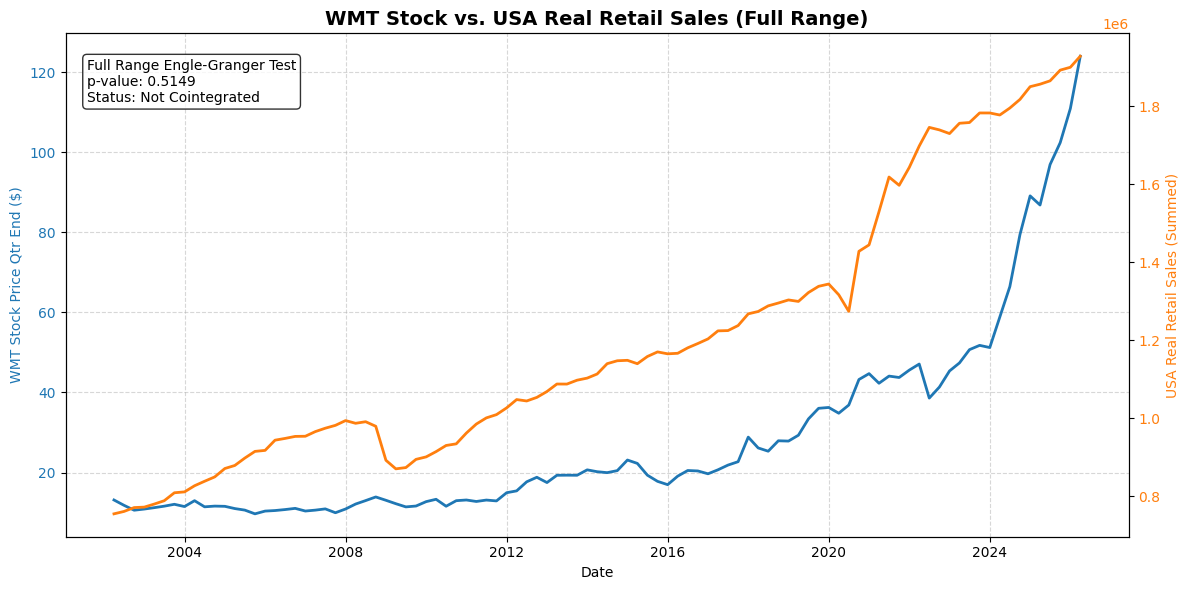

Full range database size: 97 quarters. P-Value: 0.514852


In [66]:
df_full = pd.read_csv("WMT_RETAIL_MERGED.csv")
df_full["DATE"] = pd.to_datetime(df_full["DATE"])
df_full = df_full.sort_values("DATE").reset_index(drop=True)
stock_col = "USA_WMT"    
retail_col = "USA_RETAIL_SALES"  
wmt_min, wmt_max = df_full[stock_col].min(), df_full[stock_col].max()
retail_min, retail_max = df_full[retail_col].min(), df_full[retail_col].max()

wmt_pad = (wmt_max - wmt_min) * 0.05
retail_pad = (retail_max - retail_min) * 0.05

# Co-Integration check and p-value calculation
df_full_clean = df_full.dropna(subset=[stock_col, retail_col])
_, p_val_full, _ = coint(df_full_clean[stock_col], df_full_clean[retail_col])

fig1, ax1 = plt.subplots(figsize=(12, 6))

color = "tab:blue"
ax1.set_xlabel("Date")
ax1.set_ylabel("WMT Stock Price Qtr End ($)", color=color)
ax1.plot(df_full["DATE"], df_full[stock_col], color=color, linewidth=2)
ax1.tick_params(axis="y", labelcolor=color)
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.set_ylim(wmt_min - wmt_pad, wmt_max + wmt_pad)  # Locked Scale

ax2 = ax1.twinx()
color = "tab:orange"
ax2.set_ylabel("USA Real Retail Sales (Summed)", color=color)
ax2.plot(df_full["DATE"], df_full[retail_col], color=color, linewidth=2)
ax2.tick_params(axis="y", labelcolor=color)
ax2.set_ylim(retail_min - retail_pad, retail_max + retail_pad)  # Locked Scale


txt_full = f"Full Range Engle-Granger Test\np-value: {p_val_full:.4f}\nStatus: {'Cointegrated' if p_val_full < 0.05 else 'Not Cointegrated'}"
ax1.text(0.02, 0.95, txt_full, transform=ax1.transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.title("WMT Stock vs. USA Real Retail Sales (Full Range)", fontsize=14, fontweight="bold")
fig1.tight_layout()
plt.savefig("Plot1_Full_Range.png", dpi=300)
plt.show()

print(f"Full range database size: {len(df_full_clean)} quarters. P-Value: {p_val_full:.6f}")



# 6.Short term dependency check ( using Naive Baseline & Granger Causality Test  )

Dataset isolated: 95 quarters of direct corporate history.
Corporate Revenue Growth vs. Stock Price Correlation (QoQ): 0.1184
FORECASTING PERFORMANCE EVALUATION (1-Quarter Ahead):
Naive Baseline MAE:        0.06630
SEC Revenue Indicator MAE: 0.06141
----------------------------------------------------------------------
RESULT: Corporate Revenue BEATS Naive Baseline by 7.37%.
Running Granger Causality Test (Max Lags = 4 quarters)...
Lag 1 Quarter(s) -> p-value: 0.5817 | Null Hypothesis: ACCEPTED (No leading relationship)
Lag 2 Quarter(s) -> p-value: 0.8595 | Null Hypothesis: ACCEPTED (No leading relationship)
Lag 3 Quarter(s) -> p-value: 0.9004 | Null Hypothesis: ACCEPTED (No leading relationship)
Lag 4 Quarter(s) -> p-value: 0.9219 | Null Hypothesis: ACCEPTED (No leading relationship)


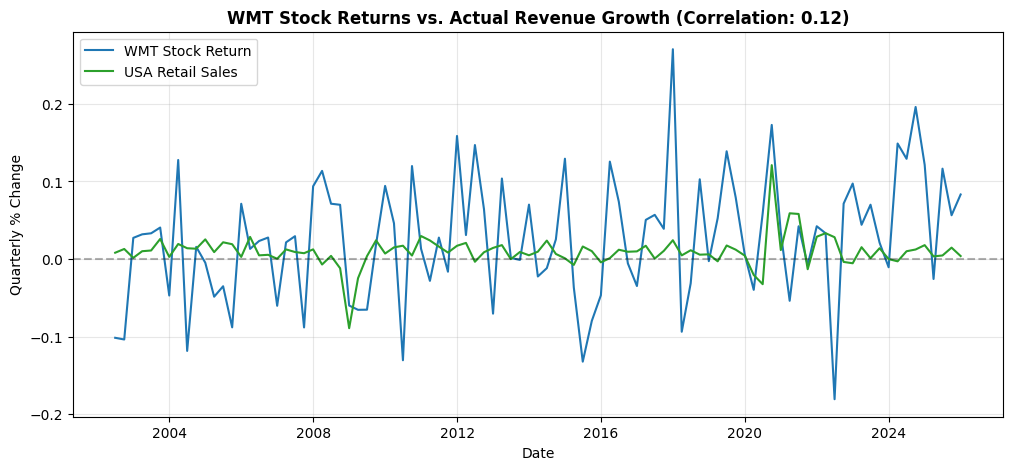

In [67]:
warnings.filterwarnings("ignore", category=FutureWarning)

stock_col = "USA_WMT"  
rev_col = "USA_RETAIL_SALES"               
df_clean = merged_df[merged_df["DATE"] <= "2025-12-31"].dropna(subset=[stock_col, rev_col]).copy()
df_clean["WMT_STOCK_GROWTH"] = df_clean[stock_col].pct_change()
df_clean["RETAIL_SALES_GROWTH"] = df_clean[rev_col].pct_change()
df_growth = df_clean.dropna(subset=["WMT_STOCK_GROWTH", "RETAIL_SALES_GROWTH"]).copy()
correlation = df_growth["WMT_STOCK_GROWTH"].corr(df_growth["RETAIL_SALES_GROWTH"])

print("=" * 70)
print(f"Dataset isolated: {len(df_growth)} quarters of direct corporate history.")
print(f"Corporate Revenue Growth vs. Stock Price Correlation (QoQ): {correlation:.4f}")
print("=" * 70)


# Naive Baseline Prediction to Actutal value comparison
df_growth["CURRENT_RETAIL_SALES_GROWTH"] = df_growth["RETAIL_SALES_GROWTH"]
df_growth["FUTURE_WMT_STOCK_GROWTH"] = df_growth["WMT_STOCK_GROWTH"].shift(-1) 


df_model = df_growth.dropna(subset=["FUTURE_WMT_STOCK_GROWTH"]).copy()


naive_preds = df_model["CURRENT_RETAIL_SALES_GROWTH"]
naive_mae = mean_absolute_error(df_model["FUTURE_WMT_STOCK_GROWTH"], naive_preds)

X_rev = df_model[["CURRENT_RETAIL_SALES_GROWTH"]].values
y_target = df_model["FUTURE_WMT_STOCK_GROWTH"].values

model = LinearRegression()
model.fit(X_rev, y_target)
indicator_preds = model.predict(X_rev)
indicator_mae = mean_absolute_error(y_target, indicator_preds)

print("FORECASTING PERFORMANCE EVALUATION (1-Quarter Ahead):")
print(f"Naive Baseline MAE:        {naive_mae:.5f}")
print(f"SEC Revenue Indicator MAE: {indicator_mae:.5f}")
print("-" * 70)

mae_improvement = ((naive_mae - indicator_mae) / naive_mae) * 100
if indicator_mae < naive_mae:
    print(f"RESULT: Corporate Revenue BEATS Naive Baseline by {mae_improvement:.2f}%.")
else:
    print(f"RESULT: Corporate Revenue FAILS to beat Baseline (Deficit: {abs(mae_improvement):.2f}%).")
print("=" * 70)


#Granger Causality Test using different lag p
granger_data = df_growth[["WMT_STOCK_GROWTH", "RETAIL_SALES_GROWTH"]]

print("Running Granger Causality Test (Max Lags = 4 quarters)...")
gc_results = grangercausalitytests(granger_data, maxlag=4, verbose=False)

for lag in gc_results:
    p_val = gc_results[lag][0]['ssr_ftest'][1]   
    status = "REJECTED (Revenue leads Stock)" if p_val < 0.05 else "ACCEPTED (No leading relationship)"
    print(f"Lag {lag} Quarter(s) -> p-value: {p_val:.4f} | Null Hypothesis: {status}")
print("=" * 70)



fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_growth["DATE"], df_growth["WMT_STOCK_GROWTH"], color="tab:blue", linewidth=1.5, label="WMT Stock Return")
ax.plot(df_growth["DATE"], df_growth["RETAIL_SALES_GROWTH"], color="tab:green", linewidth=1.5, label="USA Retail Sales")
ax.axhline(0, color='black', linestyle='--', alpha=0.3)
ax.set_ylabel("Quarterly % Change")
ax.set_xlabel("Date")
plt.title(f"WMT Stock Returns vs. Actual Revenue Growth (Correlation: {correlation:.2f})", fontsize=12, fontweight="bold")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.savefig("Revenue_vs_Stock_Returns.png", dpi=300)
plt.show()


# 7. Forecast modeling using SARIMAX

Dataset Size: 96 quarters.
Starting rolling walk-forward test for 12 quarters...
Quarter: 2023-Q | Optimal SARIMAX: (0, 1, 0)x(0, 1, 1, 4) | Forecast: $46.19 | Actual: $47.39
Quarter: 2023-Q | Optimal SARIMAX: (0, 1, 0)x(0, 1, 1, 4) | Forecast: $46.74 | Actual: $50.71
Quarter: 2023-Q | Optimal SARIMAX: (0, 1, 0)x(0, 1, 1, 4) | Forecast: $51.75 | Actual: $51.78
Quarter: 2023-Q | Optimal SARIMAX: (0, 1, 0)x(1, 1, 1, 4) | Forecast: $52.83 | Actual: $51.23
Quarter: 2024-Q | Optimal SARIMAX: (0, 1, 0)x(1, 1, 1, 4) | Forecast: $51.56 | Actual: $58.86
Quarter: 2024-Q | Optimal SARIMAX: (0, 1, 0)x(0, 1, 1, 4) | Forecast: $58.53 | Actual: $66.47
Quarter: 2024-Q | Optimal SARIMAX: (0, 1, 0)x(0, 1, 1, 4) | Forecast: $67.80 | Actual: $79.49
Quarter: 2024-Q | Optimal SARIMAX: (0, 1, 0)x(0, 1, 1, 4) | Forecast: $82.71 | Actual: $89.14
Quarter: 2025-Q | Optimal SARIMAX: (0, 1, 0)x(0, 1, 1, 4) | Forecast: $91.09 | Actual: $86.85
Quarter: 2025-Q | Optimal SARIMAX: (0, 1, 0)x(1, 1, 1, 4) | Forecast: $85

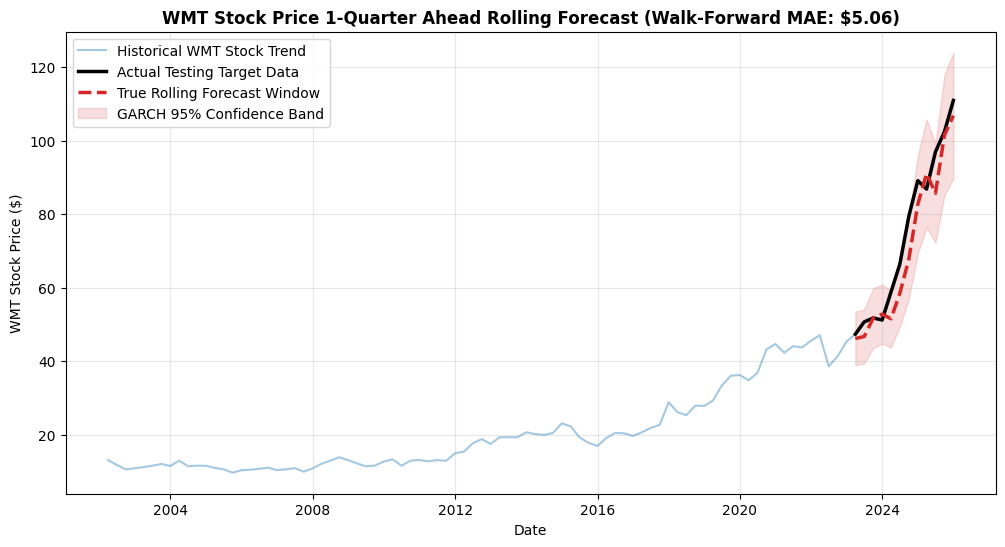

In [68]:
warnings.filterwarnings("ignore")
df = pd.read_csv("WMT_RETAIL_MERGED.csv")
df["DATE"] = pd.to_datetime(df["DATE"])
df = df.sort_values("DATE").reset_index(drop=True)
y_col = "USA_WMT"   # Target (Y)
x_col = "USA_RETAIL_SALES"  # Predictor (X)

df = df[df["DATE"] <= "2025-12-31"].dropna(subset=[y_col, x_col]).copy()
df = df.set_index("DATE").asfreq("QE", method="pad")
df["log_y"] = np.log(df[y_col])
df["log_x"] = np.log(df[x_col])
forecast_horizon = 12
total_periods = len(df)
start_index = total_periods - forecast_horizon
rolling_preds = []
rolling_vol_bands = []
actual_values = []
dates_logged = []
pct_errors=[]
print(f"Dataset Size: {total_periods} quarters.")
print(f"Starting rolling walk-forward test for {forecast_horizon} quarters...")
print("=" * 90)

#Rolling Window method
for i in range(start_index, total_periods):
    
    train_slice = df.iloc[:i]
    test_slice = df.iloc[i:i+1] 
    
    
    current_date = test_slice.index[0]
    dates_logged.append(current_date)
    actual_values.append(test_slice[y_col].values[0])
    
   
    d_var = 1 
    D_var = 1 
    s_var = 4  
    best_aic = np.inf
    best_order = (0, d_var, 0)
    best_seasonal = (0, D_var, 0, s_var)
    
    p_values = [0, 1, 2]
    q_values = [0, 1, 2]
    P_values = [0, 1]
    Q_values = [0, 1]
    
    for p in p_values:
        for q in q_values:
            for P in P_values:
                for Q in Q_values:
                    try:
                        tmp_model = SARIMAX(
                            endog=train_slice["log_y"],
                            exog=train_slice["log_x"],
                            order=(p, d_var, q),
                            seasonal_order=(P, D_var, Q, s_var),
                            enforce_stationarity=False,
                            enforce_invertibility=False
                        ).fit(disp=False)
                        
                        if tmp_model.aic < best_aic:
                            best_aic = tmp_model.aic
                            best_order = (p, d_var, q)
                            best_seasonal = (P, D_var, Q, s_var)
                    except:
                        continue
                        
   
    try:
        model_fit = SARIMAX(
            endog=train_slice["log_y"],
            exog=train_slice["log_x"],
            order=best_order,
            seasonal_order=best_seasonal,
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)
        
      
        residuals = model_fit.resid
        
     
        garch_fit = arch_model(residuals, mean='Zero', vol='GARCH', p=1, q=1).fit(disp='off')
        garch_forecast = garch_fit.forecast(horizon=1)
        next_qtr_vol = np.sqrt(garch_forecast.variance.iloc[-1].values[0])
        
       
        pred_log = model_fit.forecast(steps=1, exog=test_slice[["log_x"]])
        pred_dollar = np.exp(pred_log.values[0])
        
       
        rolling_preds.append(pred_dollar)
        rolling_vol_bands.append(next_qtr_vol)
        
        print(f"Quarter: {current_date.strftime('%Y-%Q')} | Optimal SARIMAX: {best_order}x{best_seasonal} | Forecast: ${pred_dollar:.2f} | Actual: ${test_slice[y_col].values[0]:.2f}")
        
    except Exception as e:
        print(f"Execution warning for period {current_date}: Structural failure. Using baseline fallback. Error: {e}")
        # Hard fallback to native naive pricing if structural parameters fail to converge
        rolling_preds.append(np.exp(train_slice["log_y"].values[-1]))
        rolling_vol_bands.append(0.10)
       
        
        
        
print("=" * 90)
print("ROLLING WALK-FORWARD ANALYSIS COMPLETE.")

results_df = pd.DataFrame({
    "DATE": dates_logged,
    "Actual": actual_values,
    "Forecast": rolling_preds,
    "Volatility_Sigma": rolling_vol_bands
    
   
}).set_index("DATE")

mae = mean_absolute_error(results_df["Actual"], results_df["Forecast"])
rmse = np.sqrt(mean_squared_error(results_df["Actual"], results_df["Forecast"]))
mape = np.mean(100*(np.abs(results_df["Forecast"]-results_df["Actual"])/results_df["Actual"]))

print(f"Overall Rolling Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Overall Rolling Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"Overall Mean Absolute Precentage Error (MAPE): {mape:.2f}%")
print("=" * 90)

plt.figure(figsize=(12, 6))


plt.plot(df.index, df[y_col], color="tab:blue", alpha=0.4, label="Historical WMT Stock Trend")


plt.plot(results_df.index, results_df["Actual"], color="black", linewidth=2.5, label="Actual Testing Target Data")
plt.plot(results_df.index, results_df["Forecast"], color="tab:red", linestyle="--", linewidth=2.5, label="True Rolling Forecast Window")

upper_bound = results_df["Forecast"] * (1 + (1.96 * results_df["Volatility_Sigma"]))
lower_bound = results_df["Forecast"] * (1 - (1.96 * results_df["Volatility_Sigma"]))
plt.fill_between(results_df.index, lower_bound, upper_bound, color="tab:red", alpha=0.15, label="GARCH 95% Confidence Band")

plt.ylabel("WMT Stock Price ($)")
plt.xlabel("Date")
plt.title(f"WMT Stock Price 1-Quarter Ahead Rolling Forecast (Walk-Forward MAE: ${mae:.2f})", fontsize=12, fontweight="bold")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)

plt.savefig("WMT_Rolling_SARIMAX_GARCH_Forecast.png", dpi=300)
plt.show()
